C:\Users\mordi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mordi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\mordi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


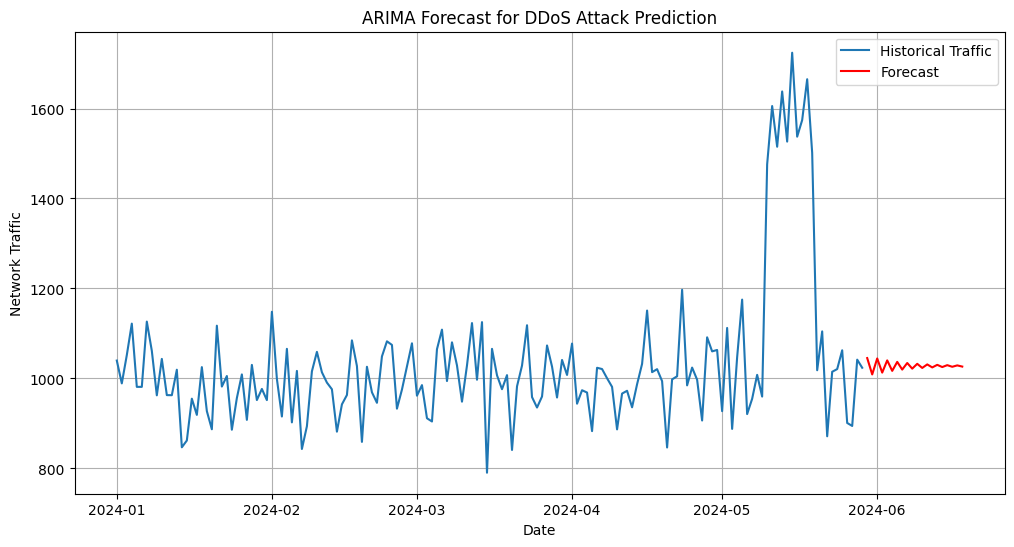

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Generate sample network traffic data
dates = pd.date_range(start="2024-01-01", periods=150, freq="D")

np.random.seed(42)
traffic = np.random.normal(1000, 80, 150)

# Simulate DDoS attack
traffic[130:140] += 600

data = pd.DataFrame({
    "Date": dates,
    "Network_Traffic": traffic
})

data.set_index("Date", inplace=True)

# Train ARIMA Model
model = ARIMA(data["Network_Traffic"], order=(2,1,2))
model_fit = model.fit()

# Forecast next 20 days
forecast = model_fit.forecast(steps=20)

forecast_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=20,
    freq="D"
)

# Plot
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Network_Traffic"], label="Historical Traffic")
plt.plot(forecast_dates, forecast, color="red", label="Forecast")
plt.title("ARIMA Forecast for DDoS Attack Prediction")
plt.xlabel("Date")
plt.ylabel("Network Traffic")
plt.legend()
plt.grid(True)
plt.show()